#**Caso de estudio**
En este documento se desarrolla y analiza un modelo de Naive Bayes orientado a la detección temprana de riesgo SARLAFT en una entidad financiera, utilizando variables socioeconómicas y transaccionales asociadas al comportamiento financiero de los clientes. El propósito del modelo es apoyar al área de cumplimiento en la identificación de clientes con alto riesgo de incurrir en operaciones relacionadas con lavado de activos, a partir de patrones observables en su información financiera.

De acuerdo con lo anterior, las variables consideradas para el análisis son las siguientes:

**Edad**: Es la edad del cliente al momento del análisis.

**Ingresos en USD**: Representan los ingresos percibidos por el cliente, expresados en dólares estadounidenses, derivados de su actividad laboral, comercial o económica.

**Gastos en USD**: Corresponden a los gastos del cliente, expresados en dólares estadounidenses, asociados a su nivel de consumo, obligaciones financieras y gastos recurrentes.

**Número de tarjetas de crédito**: Indica la cantidad de tarjetas de crédito activas que posee el cliente dentro del sistema financiero.

**Monto transado en tarjetas de crédito en USD**: Representa el valor total de las transacciones realizadas con tarjetas de crédito por el cliente, expresado en dólares estadounidenses.

**Porcentaje de crecimiento del patrimonio**: Mide la variación porcentual del patrimonio del cliente en un periodo determinado, permitiendo identificar incrementos inusuales o no coherentes con sus ingresos y comportamiento financiero.

**0. Se procede con la carga de las librerías de trabajo con IA**


In [2]:
import numpy as np #Librería numérica por excelencia.
import pandas as pd #Librería para la comunicación con archivos de Excel.

#Vamos a trabajar con Librerías específicas
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

**1. Se cargan los datos de trabajo de la base de datos Hoja0**

In [3]:
nxl='/content/2. LavadoActivos.xlsx' #Copiamos la ruta del archivo de Excel
XDB=pd.read_excel(nxl,sheet_name=0)
XDB.head() #Muestreme los datos iniciales de toda la base de datos cargada

#Seleccionamos variables de trabajo
XD=XDB[["Edad", "Ingresos en USD", "Gastos en USD", "Número de tarjetas de crédito", "Monto transado en tarjetas de crédito en USD", "Porcentaje de crecimiento del patrimonio"]] #Variables de Trabajo
XD.head(15) #La cantidad de filas filas que quiero ver
yd=XDB[["Lavado de activos"]] #Esta es la variable de decisión
yd.head()

,Lavado de activos
0,1
1,1
2,0
3,0
4,0


**2. Implementamos Modelo Navie Bayes**

In [4]:
np.set_printoptions(suppress=True,precision=2)
mnb=GaussianNB()
mnb.fit(XD,yd) #Ajustar Variables Entrada - Salida

#Mostramos las medias de las variables
u=mnb.theta_ #Medias
sigma=mnb.var_; sigma=np.sqrt(sigma) #mnb.var_ es varianza. np.sqrt es desviación estándar, que significa qué tanto se dispersan los datos alrededor del promedio
print("Edad", "Ingresos en USD", "Gastos en USD", "Número de tarjetas de crédito", "Monto transado en tarjetas de crédito en USD", "Porcentaje de crecimiento del patrimonio")
print(u)
print("Las desviaciones son:")
print(sigma)

#Límites superiores e inferiores de las variables
print('Los límites superiores son:\n',u+sigma)
print('Los límites inferiores son:\n',u-sigma)

#La primera fila es de las personas que NO están involucrados en lavado de activos
#La segunda fila es de las personas que SÍ están involucrados en lavado de activos

Edad Ingresos en USD Gastos en USD Número de tarjetas de crédito Monto transado en tarjetas de crédito en USD Porcentaje de crecimiento del patrimonio
[[   45.47  6690.73  3601.75     1.95  3090.46    44.69]
 [   44.3  70262.3  38707.28     2.02 33835.62    44.82]]
Las desviaciones son:
[[    14.71   6206.96   3219.02      2.54   2456.86     14.17]
 [    15.05 113412.26  65902.56      2.56  62991.39     15.48]]
Los limites superiores son:
 [[    60.18  12897.7    6820.77      4.49   5547.32     58.86]
 [    59.35 183674.57 104609.84      4.57  96827.01     60.3 ]]
Los limites inferiores son:
 [[    30.76    483.77    382.73     -0.58    633.61     30.51]
 [    29.25 -43149.96 -27195.27     -0.54 -29155.77     29.34]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**Análisis de Resultados**

De los resultados arrojados por el modelo, podemos observar que no hay una diferencia relevante en cuanto a las edades de las personas, ya que son muy cercanas. Podemos decir que Las personas que tienen mayores ingresos son los que tienen posibilidad de lavado de activos, al igual que las personas que tienen mayores gastos y mayores montos transados en tarjetas de crédito. También es posible observar que no hay una diferencia significativa en el número de tarjetas de crédito ni el porcentaje del crecimiento del patrimonio porque son valores prácticamente iguales.

Teniendo en cuenta lo dicho anteriormente, se afirma que las principales variables que se deben tener en cuenta para saber si una persona está involucrada en lavado de activos son los ingresos, los gastos y los montos transados en tarjetas de crédito.

**3. Se procede con la evaluación del modelo. Para la evaluación de este tipo de modelo se utiliza la matriz de confusión**

In [5]:
ydp=mnb.predict(XD) #Predigame cosas a partir de la matriz XD. Esto es lo que el modelo aprende ydp de pronóstico
cm=confusion_matrix(yd,ydp)
print(cm)

#Se determinan las métricas de la matriz de confusión
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1];TDatos=len(XDB)

#1. Exactitud: Funcionamiento general del modelo. Apartir del 75% es un buen modelo
Ex=(VP+VN)/TDatos
print("Exactitud: ", Ex)

#2. Tasa Error: Porcentaje de fallos del modelo
TEr=(FP+FN)/TDatos
print("Tasa Error: ", TEr)

#3. Sensibilidad: Cómo se comportó con respecto a los positivos solamemte
Se=VP/(VP+FN)
print("Sensibilidad: ",Se)

#4. Especificidad: Cómo se comporta pronosticando negativos
Es=VN/(VN+FP)
print("Especificidad: ",Es)

#5. Precisión: Es una  versión de cómo se comporta el modelo frente a los positivos solamente
Pr=VP/(VP+FP)
print("Precisión: ",Pr)

#6. predicción negativa: Cómo funciona el modelo pronbosticando créditos PreNegados
PrN=VN/(VN+FN)
print("Predicción Negativa: ",PrN)

[[2179   44]
 [ 145  782]]
Exactitud:  0.94
Tasa Error:  0.06
Sensibilidad:  0.8435814455231931
Especificidad:  0.9802069275753487
Precisión:  0.9467312348668281
Predicción Negativa:  0.9376075731497419


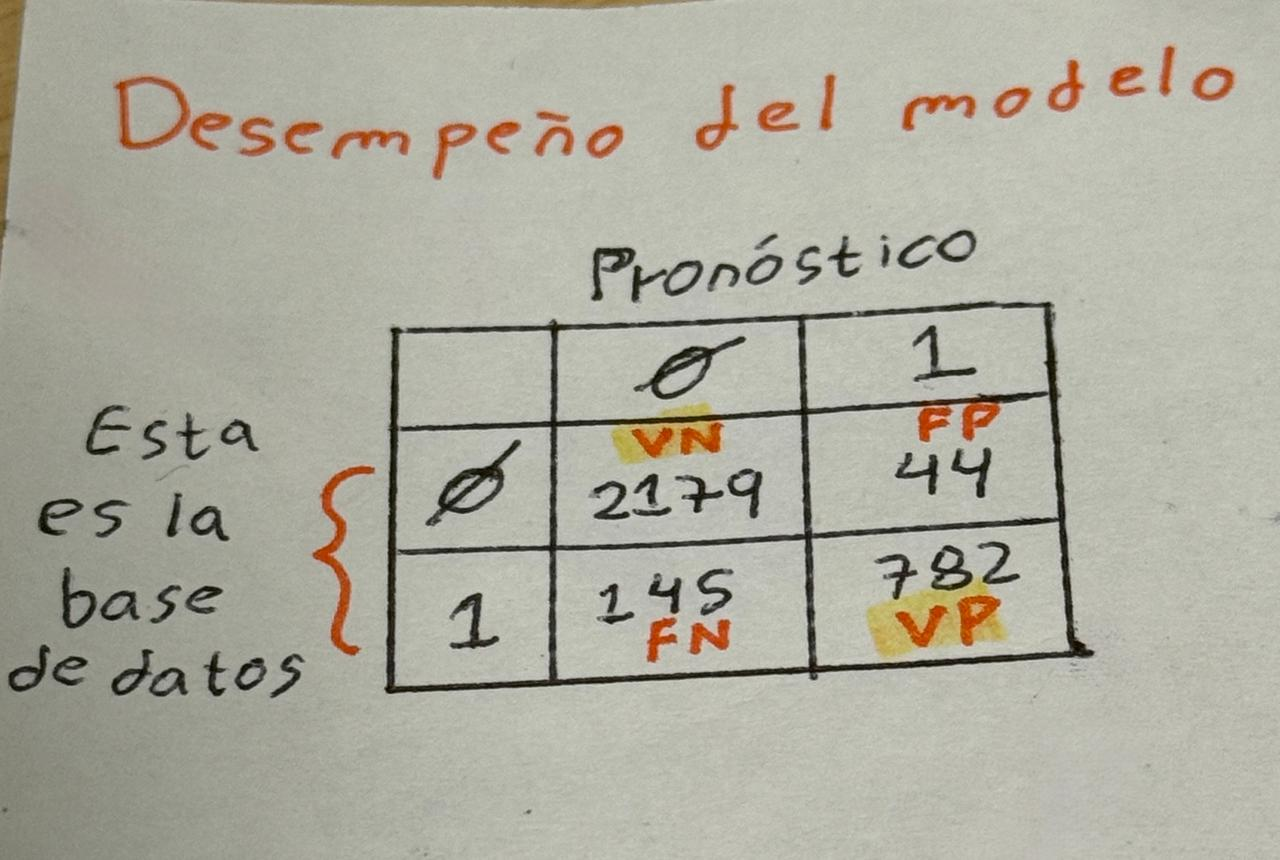

**Análisis de Resultados**

De acuerdo con los resultados, podemos observar de manera general que el modelo alcanzó una muy buena exactitud (94%), muy por encima de del porcentaje en que un modelo se considera bueno (75%), lo que indica el buen comportamiento del modelo frente a la clasificación de las personas que sí están involucradas en lavado de activos y las que no. Se destaca la Precisión con un valor por encima del 94%, lo que indica el buen funcionamiento del modelo frente a la determinación de personas involucradas al lavado de activos. Igualmente, se puede observar el buen comportamiento del modelo frente al lavado de activos, tal y como lo demuestra el índice de Especificidad del modelo, el cual estuvo por encima del 98% en promedio. También es importante mencional El modelo presenta una exactitud del 94%, lo que indica un alto nivel de acierto general en sus predicciones. Esto sugiere que, en términos globales, el modelo clasifica correctamente la mayoría de los casos evaluados.


**4. Evaluamos dos solicitantes: uno que no esté involucrado en lavado de activos y otro que sí**

In [16]:
XP=[45,6590,3601,2,3090,44]
ydc=mnb.predict([XP])
print(ydc)

if ydc==1:
  print("Esta persona SÍ está involucrada en lavado de activos")
else:
  print("Esta persona NO está involucrada en lavado de activos")

[0]
Esta persona NO está involucrada en lavado de activos


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [19]:
XP=[45,70263,31601,2,3290,41]
ydc=mnb.predict([XP])
print(ydc)

if ydc==1:
  print("Esta persona SÍ está involucrada en lavado de activos")
else:
  print("Esta persona NO está involucrada en lavado de activos")

[1]
Esta persona SÍ está involucrada en lavado de activos


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
